In [40]:
# STEP 1: Load Required Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [48]:
import os

print(os.path.abspath("/content/orders_export1.csv"))

/content/orders_export1.csv


In [49]:
import os

print(os.listdir("/content"))

['.config', '.ipynb_checkpoints', 'orders_export.csv', 'orders_export1.csv', 'sample_data']


In [59]:
# STEP 2: Load Dataset
with open("/content/orders_export1.csv", "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if i >= 20 and i <= 25:
            print(f"Line {i+1}: {line}")

Line 21: 20,CA-2014-143336,2014-08-27,2014-09-01,"Second Class",ZD-21925,"Zuschuss Donatelli",Consumer,"United States","San Francisco",California,94109,West,TEC-PH-10001949,Technology,Phones,"Cisco SPA 501G IP Phone",213.4800,3,0.20,16.0110,2014-08-27,2014-09-01

Line 22: 21,CA-2014-143336,2014-08-27,2014-09-01,"Second Class",ZD-21925,"Zuschuss Donatelli",Consumer,"United States","San Francisco",California,94109,West,OFF-BI-10002215,"Office Supplies",Binders,"Wilson Jones Hanging View Binder, White, 1"",22.7200,4,0.20,7.3840,2014-08-27,2014-09-01

Line 23: 22,CA-2016-137330,2016-12-09,2016-12-13,"Standard Class",KB-16585,"Ken Black",Corporate,"United States",Fremont,Nebraska,68025,Central,OFF-AR-10000246,"Office Supplies",Art,"Newell 318",19.4600,7,0.00,5.0596,2016-12-09,2016-12-13

Line 24: 23,CA-2016-137330,2016-12-09,2016-12-13,"Standard Class",KB-16585,"Ken Black",Corporate,"United States",Fremont,Nebraska,68025,Central,OFF-AP-10001492,"Office Supplies",Appliances,"Acco Six-Outlet 

In [60]:
with open("/content/orders_export1.csv", "r", encoding="utf-8") as f:
    print(f.readline())

Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Order_Date_latest,Ship_Date_latest



In [64]:
import csv

df = pd.read_csv(
    "/content/orders_export.csv",
    engine="python",
    quoting=csv.QUOTE_MINIMAL,
    on_bad_lines='skip'
)

In [66]:
df = pd.read_csv("/content/orders_export1.csv", on_bad_lines='skip')
print(df.shape)

(969, 23)


In [43]:
print(len(df))

969


In [3]:
print(df.head(10))

   Row_ID        Order_ID  Order_Date   Ship_Date  Shipping_Delay_Days  \
0    7470  CA-2014-138100  2014-09-15  2014-09-20                    5   
1    7469  CA-2014-138100  2014-09-15  2014-09-20                    5   
2    5202  CA-2016-103982  2016-03-03  2016-03-08                    5   
3    5201  CA-2016-103982  2016-03-03  2016-03-08                    5   
4    5200  CA-2016-103982  2016-03-03  2016-03-08                    5   
5    5199  CA-2016-103982  2016-03-03  2016-03-08                    5   
6    2231  CA-2014-128055  2014-03-31  2014-04-05                    5   
7    2230  CA-2014-128055  2014-03-31  2014-04-05                    5   
8    1160  CA-2017-147039  2017-06-29  2017-07-04                    5   
9    1300  CA-2015-121391  2015-10-04  2015-10-07                    3   

        Ship_Mode Customer_ID Customer_Name   Segment        Country  ...  \
0  Standard Class    AA-10315    Alex Avila  Consumer  United States  ...   
1  Standard Class    AA-10315  

In [4]:
print(df.shape)

(969, 26)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Row_ID                    969 non-null    int64  
 1   Order_ID                  969 non-null    object 
 2   Order_Date                969 non-null    object 
 3   Ship_Date                 969 non-null    object 
 4   Shipping_Delay_Days       969 non-null    int64  
 5   Ship_Mode                 969 non-null    object 
 6   Customer_ID               969 non-null    object 
 7   Customer_Name             969 non-null    object 
 8   Segment                   969 non-null    object 
 9   Country                   969 non-null    object 
 10  City                      969 non-null    object 
 11  State                     969 non-null    object 
 12  Postal_Code               969 non-null    int64  
 13  Region                    969 non-null    object 
 14  Product_ID

In [6]:
# STEP 3: Data Quality Assessment
# Check missing values and duplicates

print(df[['Sales','Profit','Discount']].describe())

             Sales       Profit    Discount
count   968.000000   968.000000  968.000000
mean    215.656201    36.216698    0.196303
std     543.988884   214.871018    0.966331
min       1.362000  -786.014400   -3.729600
25%      16.379500     1.909550    0.000000
50%      51.261000     8.086350    0.150000
75%     194.920000    29.274750    0.200000
max    9892.740000  4946.370000   21.445200


In [7]:
# STEP 4: Exploratory Data Analysis
# Analyze Sales, Profit and Discount distributions

print(df[['Sales','Profit','Discount']].agg(['mean','median','std','min','max']))

              Sales       Profit   Discount
mean     215.656201    36.216698   0.196303
median    51.261000     8.086350   0.150000
std      543.988884   214.871018   0.966331
min        1.362000  -786.014400  -3.729600
max     9892.740000  4946.370000  21.445200


In [8]:
print(df[['Sales','Profit','Discount']].isnull().sum())

Sales       1
Profit      1
Discount    1
dtype: int64


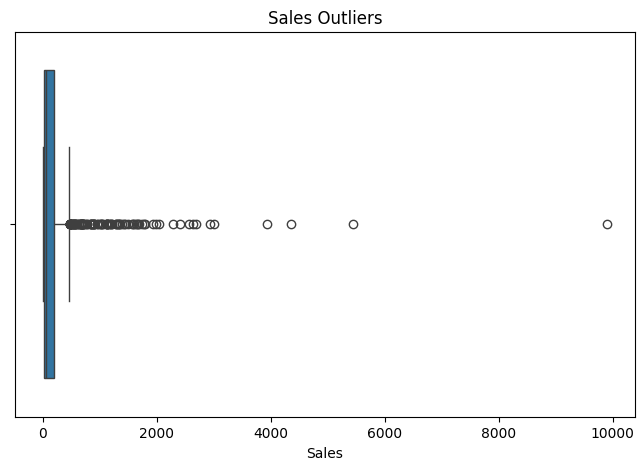

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

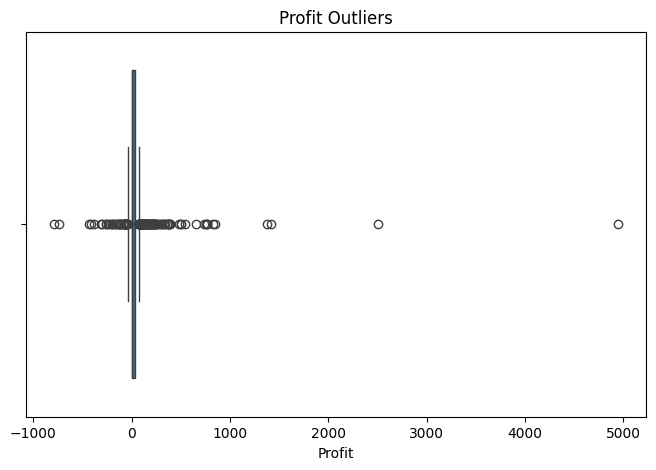

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Profit'])
plt.title("Profit Outliers")
plt.show()

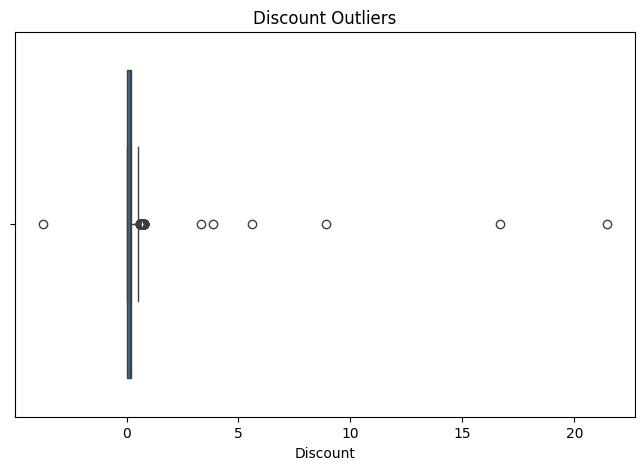

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Discount'])
plt.title("Discount Outliers")
plt.show()

In [12]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]

print("Outliers:", len(outliers))

Outliers: 107


In [13]:
df_clean = df[
    (df['Sales'] >= lower) &
    (df['Sales'] <= upper)
]

print(df_clean.shape)

(861, 26)


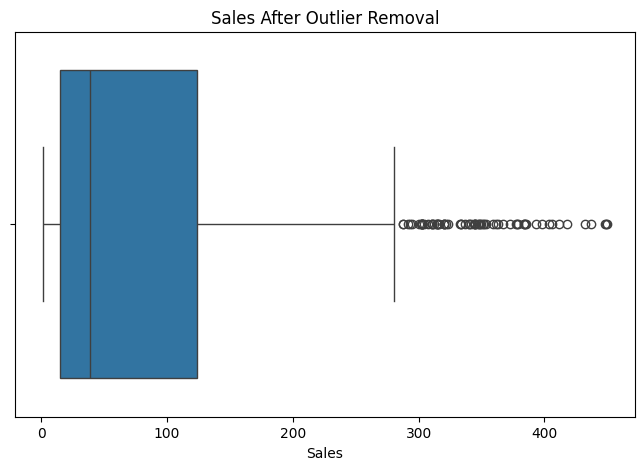

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['Sales'])
plt.title("Sales After Outlier Removal")
plt.show()

In [15]:
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Shipping_Delay_Days', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin_Pct', 'Discount_Flag', 'Customer_Lifetime_Sales', 'Customer_Lifetime_Profit']


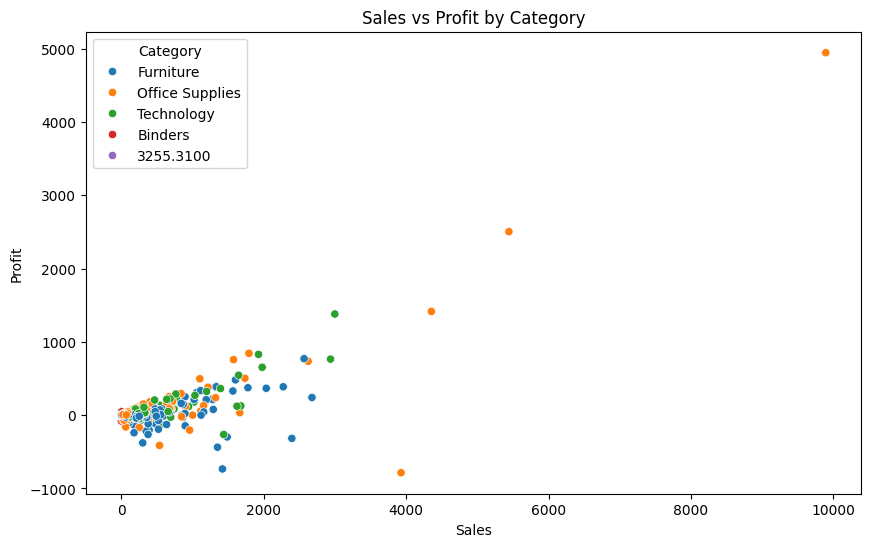

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Category'
)

plt.title('Sales vs Profit by Category')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()

In [17]:
loss_products = df[df['Profit'] < 0]

print(loss_products[['Product_Name','Category','Sales','Profit']].head())

                                         Product_Name         Category  \
5         High Speed Automatic Electric Letter Opener  Office Supplies   
46             Padded Folding Chairs, Black, 4/Carton        Furniture   
47                                 Panasonic Kx-TS550       Technology   
56                                 Akro Stacking Bins  Office Supplies   
60  Hon 2090 “Pillow Soft” Series Mid Back Swivel/...        Furniture   

       Sales    Profit  
5   3930.072 -786.0144  
46   170.058   -4.8588  
47    82.782  -15.1767  
56    12.624   -2.5248  
60   449.568  -73.0548  


In [18]:
print("Loss Transactions:", len(loss_products))

Loss Transactions: 165


In [19]:
category_profit = df.groupby('Category')['Profit'].sum()

print(category_profit)

Category
3255.3100              0.0000
Binders              157.7500
Furniture           4034.2411
Office Supplies    20524.1517
Technology         10341.6204
Name: Profit, dtype: float64


In [20]:
import pandas as pd

corr_matrix = df[['Discount','Quantity','Profit']].corr()

print(corr_matrix)

          Discount  Quantity    Profit
Discount  1.000000 -0.085654 -0.029908
Quantity -0.085654  1.000000  0.181514
Profit   -0.029908  0.181514  1.000000


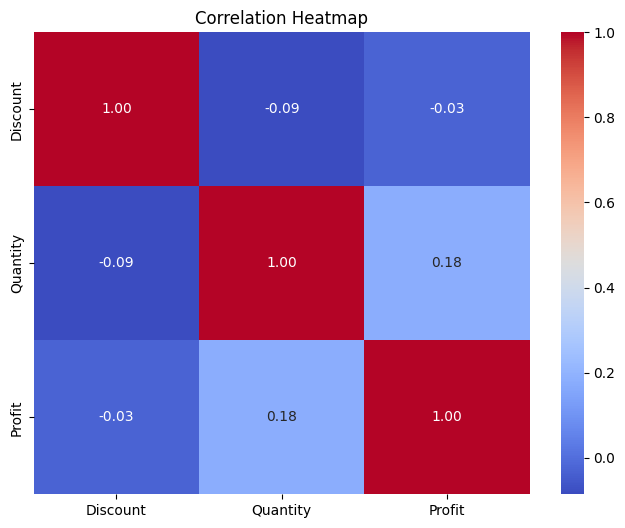

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [22]:
df['Discount_Bucket'] = pd.cut(
    df['Discount'],
    bins=[0,0.1,0.2,0.3,0.4,0.5,1.0]
)

threshold_report = df.groupby('Discount_Bucket')['Profit'].mean()

print(threshold_report)

Discount_Bucket
(0.0, 0.1]     62.803429
(0.1, 0.2]     19.010459
(0.2, 0.3]    -38.039328
(0.3, 0.4]   -131.841872
(0.4, 0.5]   -152.248617
(0.5, 1.0]    -43.365072
Name: Profit, dtype: float64


/tmp/ipykernel_458/2164799551.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  threshold_report = df.groupby('Discount_Bucket')['Profit'].mean()


In [23]:
discount_analysis = (
    df.groupby('Discount')['Profit']
      .mean()
      .reset_index()
)

loss_threshold = discount_analysis[
    discount_analysis['Profit'] < 0
]

print(loss_threshold.head())

   Discount      Profit
0   -3.7296  -80.000000
5    0.3000  -38.039328
6    0.3200 -377.346600
7    0.4000 -101.153781
8    0.5000 -152.248617


In [24]:
# STEP 5: RFM Customer Segmentation
# Calculate Recency, Frequency and Monetary values

import pandas as pd

# Convert date column
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Reference date (1 day after latest order)
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

# Calculate RFM
rfm = df.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'nunique',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer_ID','Recency','Frequency','Monetary']

print(rfm.head())

  Customer_ID  Recency  Frequency  Monetary
0    AA-10315      179          5  5563.560
1    AA-10375       14          9  1050.130
2    AA-10480      254          4  1782.872
3    AA-10645       50          6  4455.895
4    AB-10015      410          3   886.156


In [25]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

print(rfm[['Customer_ID','RFM_Score']].head())


  Customer_ID RFM_Score
0    AA-10315       125
1    AA-10375       552
2    AA-10480       113
3    AA-10645       335
4    AB-10015       112


In [26]:
def customer_segment(row):

    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'VIP'

    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'At Risk'

    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(customer_segment, axis=1)

print(
    rfm.groupby('Segment')
       .agg({
           'Customer_ID':'count',
           'Monetary':'mean'
       })
)

         Customer_ID     Monetary
Segment                          
At Risk           17  1407.021271
Regular           55  2257.106175
VIP               11  5517.727364


In [27]:
vip_customers = rfm[rfm['Segment']=='VIP']

print(
    vip_customers[
        ['Customer_ID','Recency','Frequency',
         'Monetary','RFM_Score']
    ]
)

   Customer_ID  Recency  Frequency   Monetary RFM_Score
6     AB-10105       36          9  14355.611       455
12    AC-10450        6          7   5527.846       545
15    AD-10180       24          7   6101.000       445
28    AH-10075       29         10   3250.337       454
31    AH-10210        1          9   4805.344       555
35    AI-10855        8         10   4375.786       554
52    AS-10090       23          9   3157.870       454
59    AT-10735        8         10   3831.864       554
61    AW-10930       41          7   2851.444       444
65    BB-11545       23          9   6765.728       455
67    BD-11320       28         11   5672.171       455


In [28]:
at_risk = rfm[rfm['Segment']=='At Risk']

print(
    at_risk[
        ['Customer_ID','Recency','Frequency',
         'Monetary','RFM_Score']
    ]
)

   Customer_ID  Recency  Frequency   Monetary RFM_Score
0     AA-10315      179          5  5563.5600       125
2     AA-10480      254          4  1782.8720       113
4     AB-10015      410          3   886.1560       112
11    AC-10420      227          3   891.5600       112
13    AC-10615      114          4  2481.3240       214
14    AC-10660      277          5   657.3160       121
17    AF-10885      410          4   861.5650       112
18    AG-10270      273          5  2565.2580       124
19    AG-10300      113          4   349.2600       211
21    AG-10390      109          5   200.9450       221
23    AG-10525      840          4  1411.3220       113
32    AH-10465      225          4  2406.4316       123
42    AO-10810      496          1   161.2800       111
45    AR-10345      106          4  1055.6940       222
46    AR-10405      120          5  2236.1280       223
49    AR-10570      529          1    88.1500       111
69    BD-11560      273          2   320.5400   

In [29]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

df['Shipping_Delay_Days'] = (
    df['Ship_Date'] -
    df['Order_Date']
).dt.days

In [30]:
print(df['Shipping_Delay_Days'].describe())

count    969.000000
mean       3.945304
std        1.645838
min        0.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        7.000000
Name: Shipping_Delay_Days, dtype: float64


In [31]:
df[df['Shipping_Delay_Days'] < 0]

,Row_ID,Order_ID,Order_Date,Ship_Date,Shipping_Delay_Days,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,...,Sub_Category,Sales,Quantity,Discount,Profit,Profit_Margin_Pct,Discount_Flag,Customer_Lifetime_Sales,Customer_Lifetime_Profit,Discount_Bucket


In [32]:
# Missing Values
print(df.isnull().sum())

# Duplicate Records
print(df.duplicated().sum())

# Date Validation
print(df['Order_Date'].min())
print(df['Order_Date'].max())

# Shipping Delay Validation
print(df['Shipping_Delay_Days'].describe())

# RFM Validation
print(rfm.head())

# Correlation Validation
print(df[['Discount','Quantity','Profit']].corr())

Row_ID                        0
Order_ID                      0
Order_Date                    0
Ship_Date                     0
Shipping_Delay_Days           0
Ship_Mode                     0
Customer_ID                   0
Customer_Name                 0
Segment                       0
Country                       0
City                          0
State                         0
Postal_Code                   0
Region                        0
Product_ID                    0
Product_Name                  0
Category                      0
Sub_Category                  0
Sales                         1
Quantity                      1
Discount                      1
Profit                        1
Profit_Margin_Pct             1
Discount_Flag                 1
Customer_Lifetime_Sales       1
Customer_Lifetime_Profit      8
Discount_Bucket             482
dtype: int64
0
2014-01-10 00:00:00
2017-12-24 00:00:00
count    969.000000
mean       3.945304
std        1.645838
min        0.000000
2

In [36]:
import pandas as pd

df = pd.read_csv("/content/orders_export_day9.csv", on_bad_lines='skip')

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
average_order = df["Sales"].mean()
profit_margin = (total_profit / total_sales) * 100

print(round(total_sales,2))
print(round(total_profit,2))
print(total_orders)
print(round(average_order,2))
print(round(profit_margin,2))

208755.2
35057.76
499
215.66
16.79


In [37]:
len(df)

969

In [39]:
print(df.head())
print(df.columns)

   Row_ID        Order_ID  Order_Date   Ship_Date  Shipping_Delay_Days  \
0    7470  CA-2014-138100  2014-09-15  2014-09-20                    5   
1    7469  CA-2014-138100  2014-09-15  2014-09-20                    5   
2    5202  CA-2016-103982  2016-03-03  2016-03-08                    5   
3    5201  CA-2016-103982  2016-03-03  2016-03-08                    5   
4    5200  CA-2016-103982  2016-03-03  2016-03-08                    5   

        Ship_Mode Customer_ID Customer_Name   Segment        Country  ...  \
0  Standard Class    AA-10315    Alex Avila  Consumer  United States  ...   
1  Standard Class    AA-10315    Alex Avila  Consumer  United States  ...   
2  Standard Class    AA-10315    Alex Avila  Consumer  United States  ...   
3  Standard Class    AA-10315    Alex Avila  Consumer  United States  ...   
4  Standard Class    AA-10315    Alex Avila  Consumer  United States  ...   

          Category Sub_Category    Sales Quantity Discount   Profit  \
0        Furniture  F